<a href="https://www.kaggle.com/code/lalit7881/heart-failure-readmission-sdoh-eda?scriptVersionId=314014426" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nudratabbas/heart-failure-readmission-and-sdoh-dataset/heart_failure_readmission_dataset.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/nudratabbas/heart-failure-readmission-and-sdoh-dataset/heart_failure_readmission_dataset.csv")

In [3]:
df.head()

,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
0,12911,76,Male,23.9,738,135.3,1.58,151,93,1,1,0,0.98,Medium,12.4,0
1,12521,77,Male,32.3,405,143.0,1.50,107,74,1,0,1,0.66,Medium,38.8,1
2,10155,42,Male,29.3,399,NaN,1.43,121,97,1,0,1,0.93,Low,43.5,1
3,12088,83,Female,29.1,524,135.1,0.91,114,66,0,1,1,0.54,Low,33.3,1
4,10792,48,Female,24.2,301,139.5,0.54,122,79,1,1,1,0.78,High,21.3,0


In [4]:
df.tail()

,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
2995,10499,85,Male,23.2,249,136.4,0.84,126,102,0,0,1,0.54,Medium,9.1,1
2996,10747,70,Male,26.1,125,139.4,0.71,135,82,0,1,1,0.57,Medium,47.6,0
2997,11948,69,Male,30.0,362,134.2,1.95,148,61,0,0,1,0.99,Medium,31.7,1
2998,12148,90,Female,26.2,503,143.6,0.16,145,56,1,1,0,0.61,Low,39.0,1
2999,12487,65,Female,24.3,456,134.3,0.99,119,116,0,0,1,0.40,Medium,48.8,1


In [5]:
df.isnull().sum()

patient_id                  0
age                         0
gender                      0
bmi                        90
bnp                         0
sodium                     90
creatinine                 90
systolic_bp                 0
heart_rate                  0
ace_inhibitor               0
beta_blocker                0
diuretic                    0
adherence_score             0
income_level                0
distance_to_hospital_km     0
readmitted_30d              0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

patient_id                   int64
age                          int64
gender                      object
bmi                        float64
bnp                          int64
sodium                     float64
creatinine                 float64
systolic_bp                  int64
heart_rate                   int64
ace_inhibitor                int64
beta_blocker                 int64
diuretic                     int64
adherence_score            float64
income_level                object
distance_to_hospital_km    float64
readmitted_30d               int64
dtype: object

In [8]:
df.shape

(3000, 16)

In [9]:
df.columns

Index(['patient_id', 'age', 'gender', 'bmi', 'bnp', 'sodium', 'creatinine',
       'systolic_bp', 'heart_rate', 'ace_inhibitor', 'beta_blocker',
       'diuretic', 'adherence_score', 'income_level',
       'distance_to_hospital_km', 'readmitted_30d'],
      dtype='object')

In [10]:
df.nunique()

patient_id                 3000
age                          51
gender                        2
bmi                         264
bnp                         818
sodium                      217
creatinine                  262
systolic_bp                 120
heart_rate                   92
ace_inhibitor                 2
beta_blocker                  2
diuretic                      2
adherence_score              61
income_level                  3
distance_to_hospital_km     490
readmitted_30d                2
dtype: int64

In [11]:
df.describe()

,patient_id,age,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,distance_to_hospital_km,readmitted_30d
count,3000.000000,3000.000000,2910.000000,3000.000000,2910.000000,2910.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,11499.500000,65.254333,28.109038,406.308000,138.089210,1.195082,129.588667,79.364000,0.521667,0.503333,0.489000,0.699377,25.399533,0.411333
std,866.169729,14.806465,4.949035,232.273101,4.031886,0.490563,20.257120,15.269465,0.499614,0.500072,0.499962,0.172973,14.145746,0.492157
min,10000.000000,40.000000,8.800000,50.000000,124.700000,-0.590000,61.000000,19.000000,0.000000,0.000000,0.000000,0.400000,1.000000,0.000000
25%,10749.750000,52.000000,24.800000,225.000000,135.300000,0.870000,116.000000,69.000000,0.000000,0.000000,0.000000,0.550000,12.800000,0.000000
50%,11499.500000,65.000000,28.100000,392.000000,138.100000,1.200000,130.000000,79.000000,1.000000,1.000000,0.000000,0.700000,25.450000,0.000000
75%,12249.250000,78.000000,31.500000,569.000000,140.800000,1.520000,143.000000,90.000000,1.000000,1.000000,1.000000,0.850000,37.525000,1.000000
max,12999.000000,90.000000,44.900000,1381.000000,151.600000,2.940000,196.000000,147.000000,1.000000,1.000000,1.000000,1.000000,50.000000,1.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               3000 non-null   int64  
 1   age                      3000 non-null   int64  
 2   gender                   3000 non-null   object 
 3   bmi                      2910 non-null   float64
 4   bnp                      3000 non-null   int64  
 5   sodium                   2910 non-null   float64
 6   creatinine               2910 non-null   float64
 7   systolic_bp              3000 non-null   int64  
 8   heart_rate               3000 non-null   int64  
 9   ace_inhibitor            3000 non-null   int64  
 10  beta_blocker             3000 non-null   int64  
 11  diuretic                 3000 non-null   int64  
 12  adherence_score          3000 non-null   float64
 13  income_level             3000 non-null   object 
 14  distance_to_hospital_km 

## EDA

   patient_id  age  gender   bmi  bnp  sodium  creatinine  systolic_bp  \
0       12911   76    Male  23.9  738   135.3        1.58          151   
1       12521   77    Male  32.3  405   143.0        1.50          107   
2       10155   42    Male  29.3  399     NaN        1.43          121   
3       12088   83  Female  29.1  524   135.1        0.91          114   
4       10792   48  Female  24.2  301   139.5        0.54          122   

   heart_rate  ace_inhibitor  beta_blocker  diuretic  adherence_score  \
0          93              1             1         0             0.98   
1          74              1             0         1             0.66   
2          97              1             0         1             0.93   
3          66              0             1         1             0.54   
4          79              1             1         1             0.78   

  income_level  distance_to_hospital_km  readmitted_30d  
0       Medium                     12.4               0  


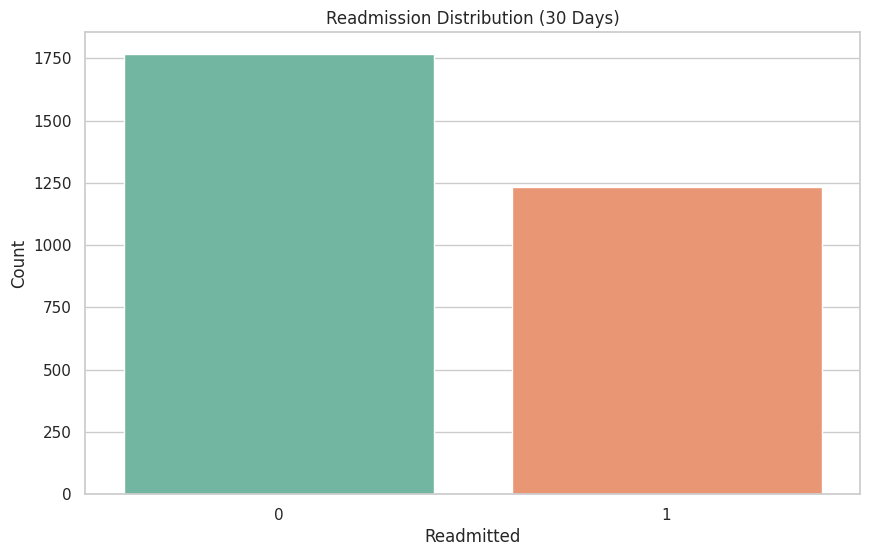

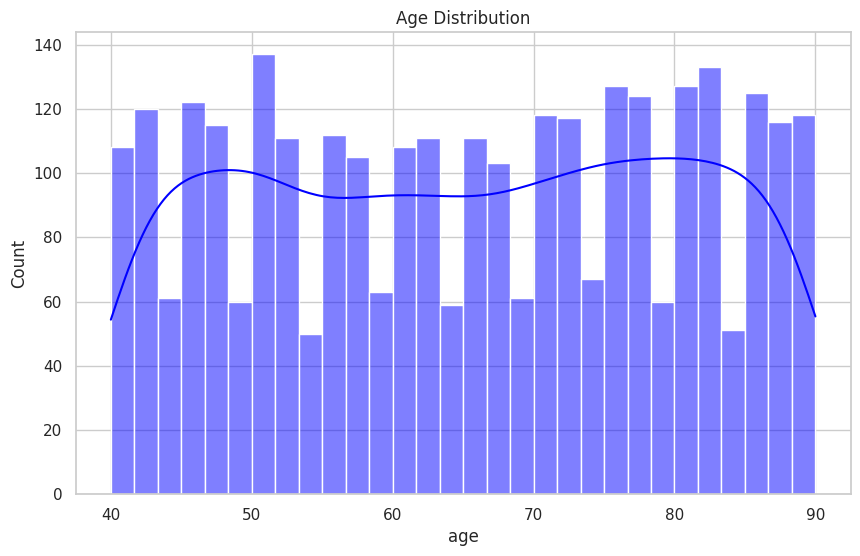

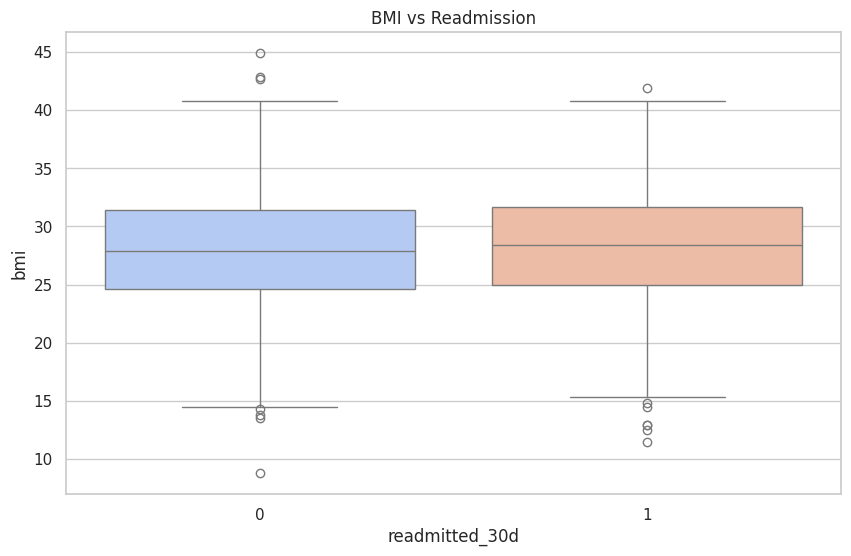

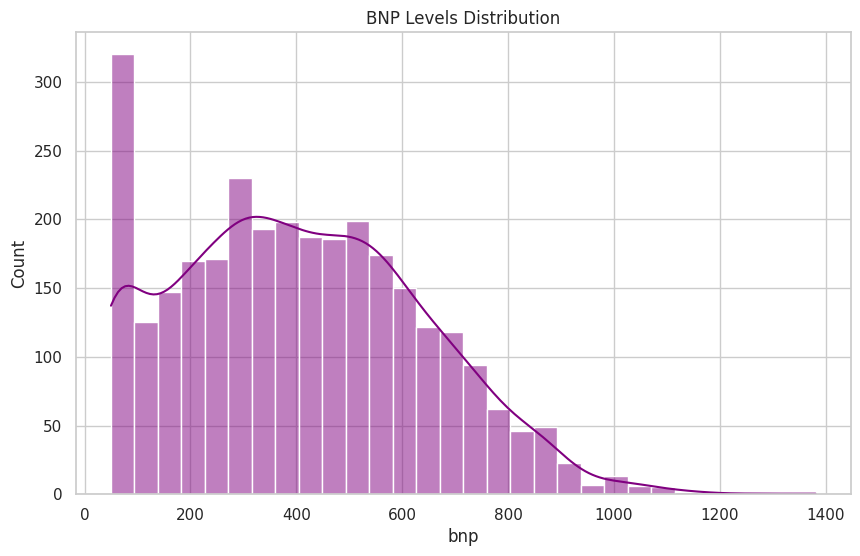

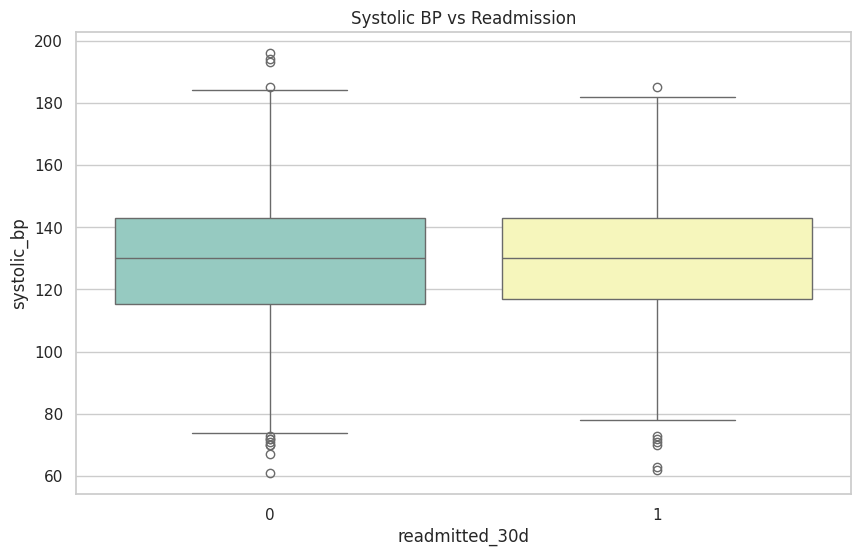

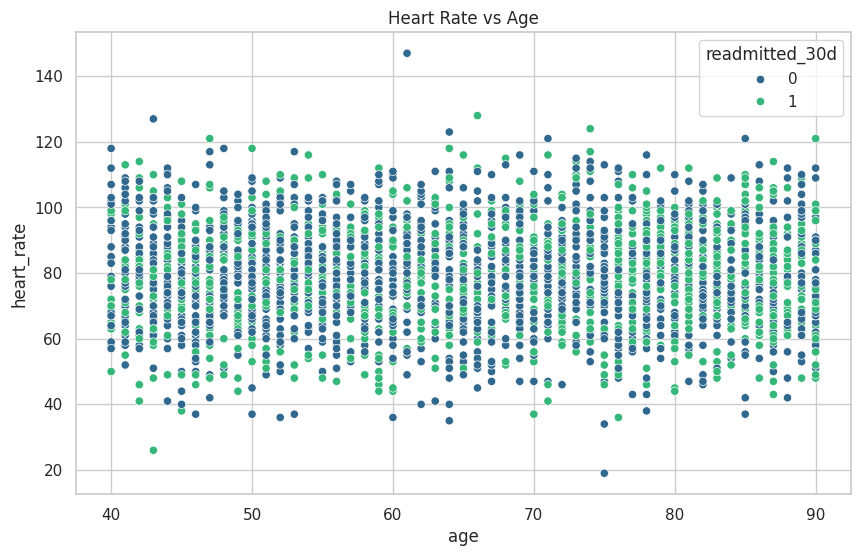

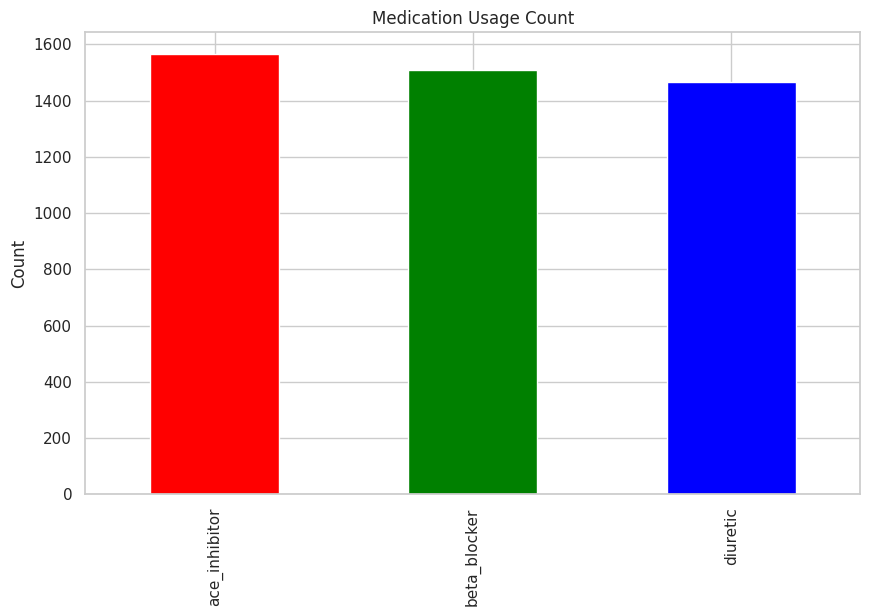

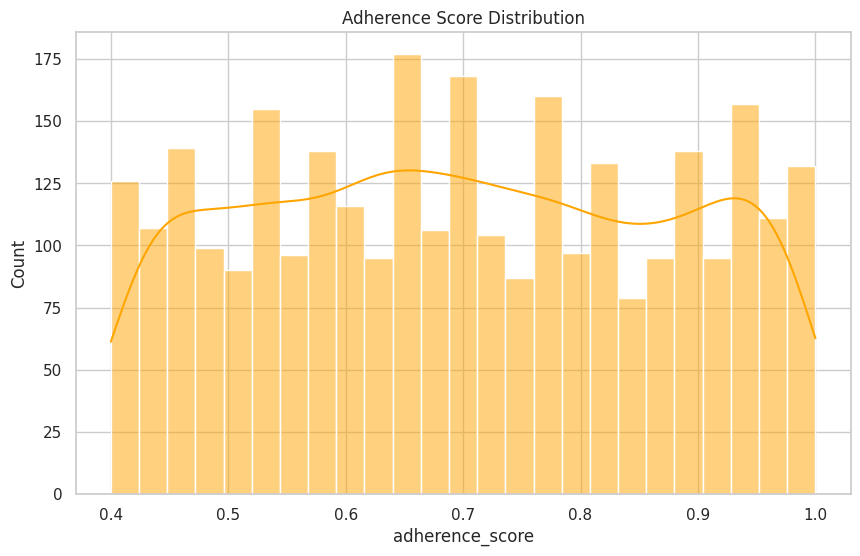

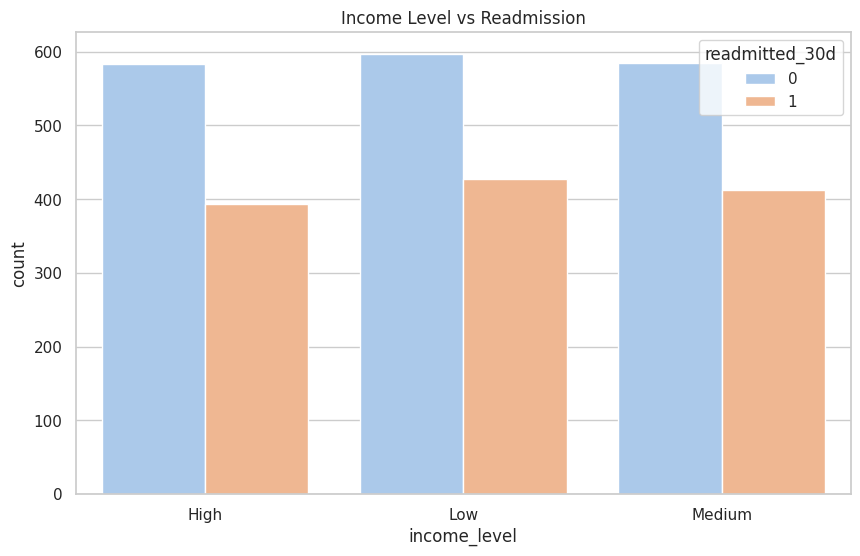

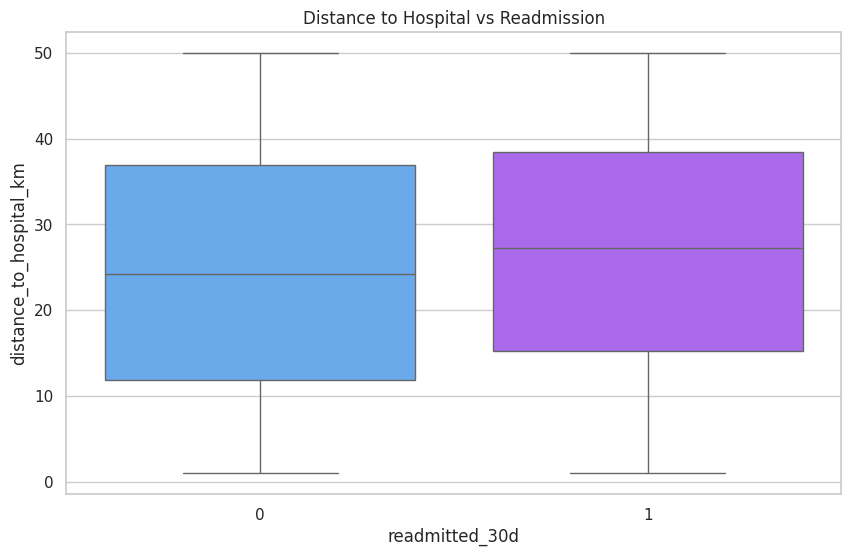

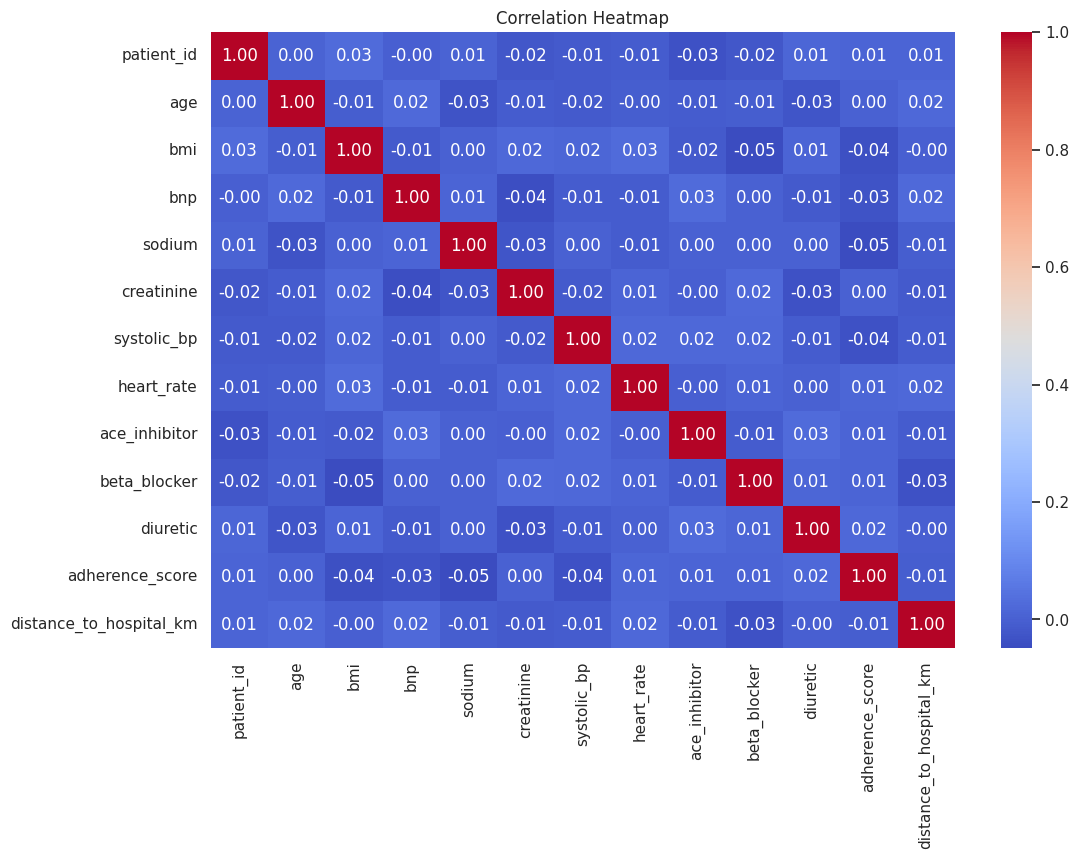

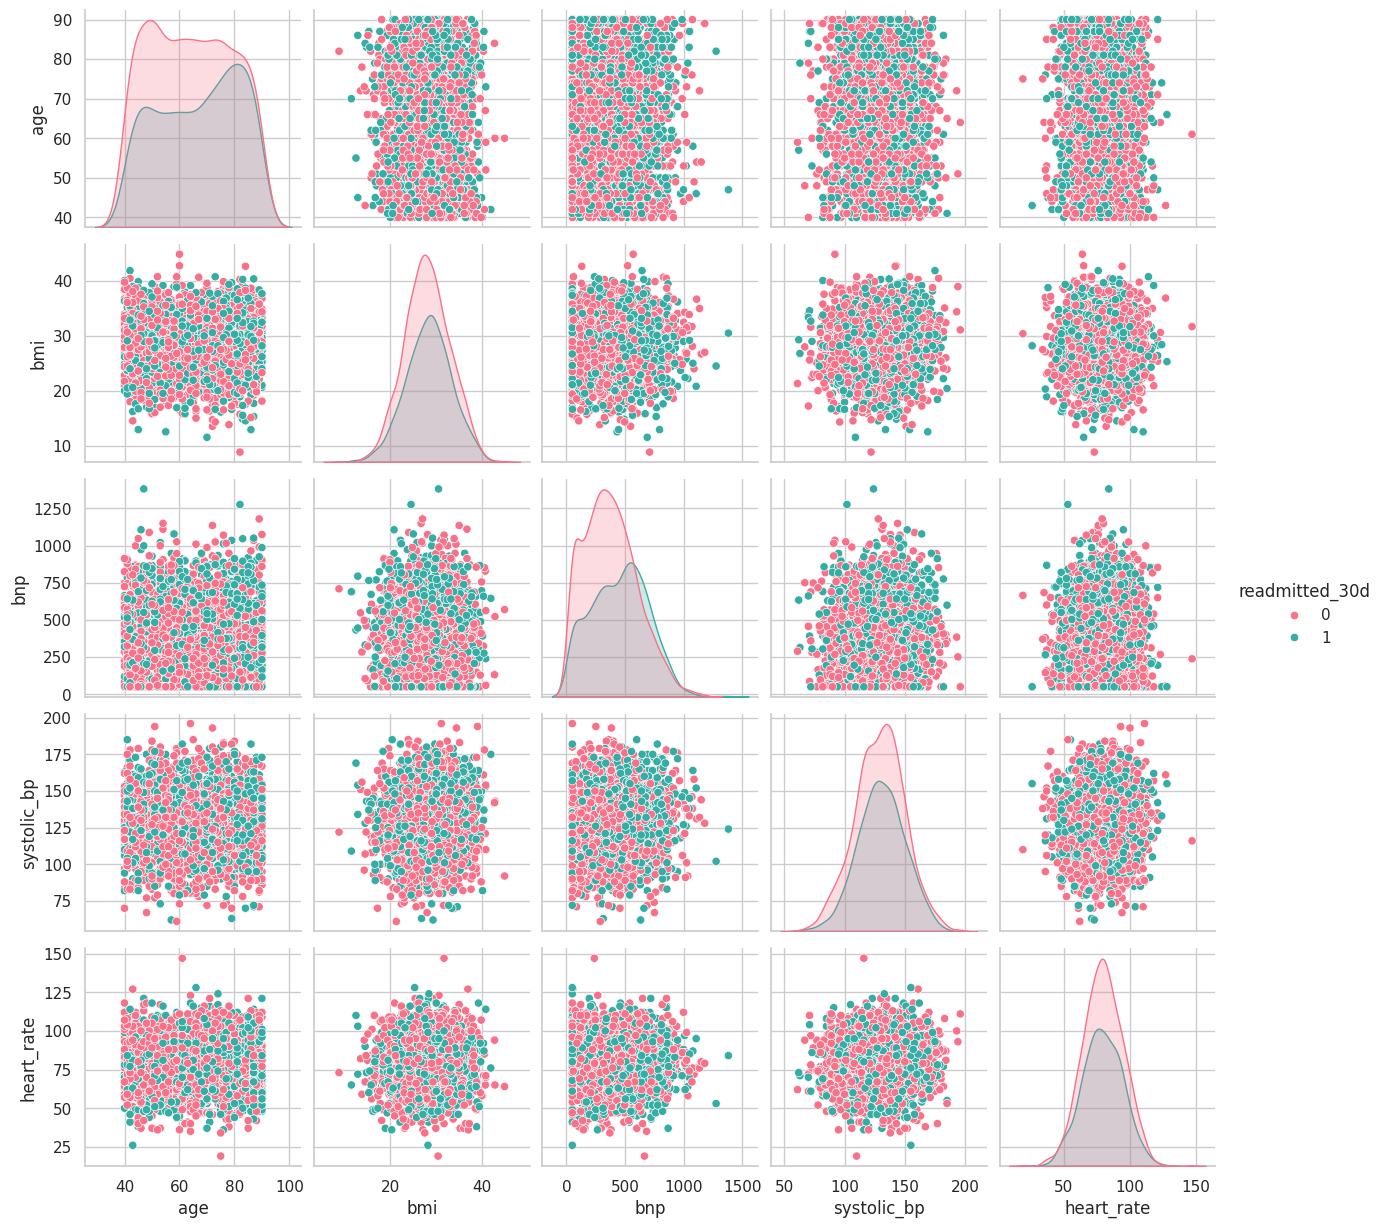

In [13]:
# Style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ================================
# Basic Info
# ================================
print(df.head())
print(df.info())
print(df.describe())

# ================================
# Convert categorical if needed
# ================================
df['gender'] = df['gender'].astype('category')
df['income_level'] = df['income_level'].astype('category')
df['readmitted_30d'] = df['readmitted_30d'].astype('category')

# ================================
# 1. Target Distribution
# ================================
plt.figure()
sns.countplot(x='readmitted_30d', data=df, palette='Set2')
plt.title("Readmission Distribution (30 Days)")
plt.xlabel("Readmitted")
plt.ylabel("Count")
plt.show()

# ================================
# 2. Age Distribution
# ================================
plt.figure()
sns.histplot(df['age'], bins=30, kde=True, color='blue')
plt.title("Age Distribution")
plt.show()

# ================================
# 3. BMI vs Readmission
# ================================
plt.figure()
sns.boxplot(x='readmitted_30d', y='bmi', data=df, palette='coolwarm')
plt.title("BMI vs Readmission")
plt.show()

# ================================
# 4. BNP Distribution
# ================================
plt.figure()
sns.histplot(df['bnp'], bins=30, color='purple', kde=True)
plt.title("BNP Levels Distribution")
plt.show()

# ================================
# 5. Blood Pressure vs Readmission
# ================================
plt.figure()
sns.boxplot(x='readmitted_30d', y='systolic_bp', data=df, palette='Set3')
plt.title("Systolic BP vs Readmission")
plt.show()

# ================================
# 6. Heart Rate Scatter
# ================================
plt.figure()
sns.scatterplot(
    x='age',
    y='heart_rate',
    hue='readmitted_30d',
    palette='viridis',
    data=df
)
plt.title("Heart Rate vs Age")
plt.show()

# ================================
# 7. Medication Usage Count
# ================================
med_cols = ['ace_inhibitor', 'beta_blocker', 'diuretic']
df_med = df[med_cols].sum()

plt.figure()
df_med.plot(kind='bar', color=['red', 'green', 'blue'])
plt.title("Medication Usage Count")
plt.ylabel("Count")
plt.show()

# ================================
# 8. Adherence Score Distribution
# ================================
plt.figure()
sns.histplot(df['adherence_score'], bins=25, color='orange', kde=True)
plt.title("Adherence Score Distribution")
plt.show()

# ================================
# 9. Income Level vs Readmission
# ================================
plt.figure()
sns.countplot(
    x='income_level',
    hue='readmitted_30d',
    data=df,
    palette='pastel'
)
plt.title("Income Level vs Readmission")
plt.show()

# ================================
# 10. Distance to Hospital
# ================================
plt.figure()
sns.boxplot(
    x='readmitted_30d',
    y='distance_to_hospital_km',
    data=df,
    palette='cool'
)
plt.title("Distance to Hospital vs Readmission")
plt.show()

# ================================
# 11. Correlation Heatmap
# ================================
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

# ================================
# 12. Pairplot (Important Features)
# ================================
sns.pairplot(
    df[['age', 'bmi', 'bnp', 'systolic_bp', 'heart_rate', 'readmitted_30d']],
    hue='readmitted_30d',
    palette='husl'
)
plt.show()

## Feature engineering

Dataset Shape: (3000, 16)

Missing Values:
 patient_id                  0
age                         0
gender                      0
bmi                        90
bnp                         0
sodium                     90
creatinine                 90
systolic_bp                 0
heart_rate                  0
ace_inhibitor               0
beta_blocker                0
diuretic                    0
adherence_score             0
income_level                0
distance_to_hospital_km     0
readmitted_30d              0
dtype: int64

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.65      0.80      0.72       353
           1       0.57      0.39      0.47       247

    accuracy                           0.63       600
   macro avg       0.61      0.59      0.59       600
weighted avg       0.62      0.63      0.61       600


===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.

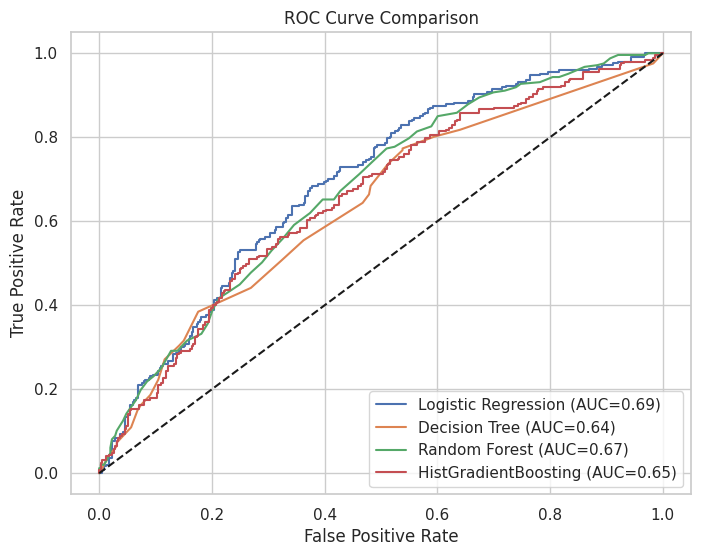


Final Model Comparison:
                      Accuracy  Precision    Recall  F1 Score   ROC-AUC
Logistic Regression   0.630000   0.573964  0.392713  0.466346  0.690553
Decision Tree         0.630000   0.600000  0.303644  0.403226  0.637405
Random Forest         0.630000   0.574850  0.388664  0.463768  0.673980
HistGradientBoosting  0.641667   0.579208  0.473684  0.521158  0.654655

Best Model based on ROC-AUC: Logistic Regression


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report
)

# ==========================================
# 3. Basic Check
# ==========================================
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

# ==========================================
# 4. Define Features & Target
# ==========================================
X = df.drop(columns=['patient_id', 'readmitted_30d'])
y = df['readmitted_30d']

# ==========================================
# 5. Column Types
# ==========================================
categorical_cols = ['gender', 'income_level']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# ==========================================
# 6. Preprocessing (NO DATA LEAKAGE)
# ==========================================
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# ==========================================
# 7. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================
# 8. Models
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier()
}

# ==========================================
# 9. Training + Evaluation
# ==========================================
results = {}

plt.figure(figsize=(8,6))

for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Probabilities (handle models without predict_proba)
    if hasattr(pipeline.named_steps['model'], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = pipeline.decision_function(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results[name] = [acc, prec, rec, f1, roc_auc]
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")
    
    # Print Report
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))

# ==========================================
# 10. ROC Curve Plot
# ==========================================
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ==========================================
# 11. Results Table
# ==========================================
results_df = pd.DataFrame(
    results,
    index=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
).T

print("\nFinal Model Comparison:")
print(results_df)

# ==========================================
# 12. Best Model
# ==========================================
best_model = results_df['ROC-AUC'].idxmax()
print(f"\nBest Model based on ROC-AUC: {best_model}")

## Thank you...pls upvote!!!!!!!!!!